In [1]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))
from preprocessing.event_dataset import EventDataset


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
events_path = os.path.join(PROJECT_ROOT, "events/train/Train001/events.h5")
event_files = [
    events_path
]

dataset = EventDataset(
    event_files=event_files,
    sequence_length=100,
    time_window=0.1,
    encoding="rate",
    overlap=0.0
)

print("Total samples:", len(dataset))


EVENT DATASET INITIALIZED
Files: 1
Total samples: 39
Sequence length: 100 time steps
Time window: 100.0 ms
Resolution: 240×360
Encoding: rate
Overlap: 0%
Total samples: 39


In [3]:
sample = dataset[0]

spikes = sample['spikes']
events = sample['events']

print("Spikes shape:", spikes.shape)   # (2, H, W, T)
print("Events shape:", events.shape)   # (2, H, W)
print("Number of events:", sample['n_events'])


Spikes shape: (2, 240, 360, 100)
Events shape: (2, 240, 360)
Number of events: 11356


In [4]:
# Debug: Check raw data in h5 file
import h5py

with h5py.File(events_path, 'r') as f:
    print("Keys:", list(f.keys()))
    if 'events' in f:
        print("Events keys:", list(f['events'].keys()))
        t = f['events/t'][:]
        print(f"Raw timestamps - min: {t.min()}, max: {t.max()}")
        print(f"Timestamp range (assuming microseconds -> seconds): {(t.max() - t.min()) * 1e-6:.6f} s")
        print(f"Total events in file: {len(t)}")

Keys: ['events']
Events keys: ['p', 't', 'x', 'y']
Raw timestamps - min: 0, max: 3933333
Timestamp range (assuming microseconds -> seconds): 3.933333 s
Total events in file: 350916


In [5]:
# Debug: Check what _load_events returns
loaded_events = dataset._load_events(0)
print(f"Loaded events: {loaded_events}")
print(f"Type: {type(loaded_events)}")
if loaded_events is not None:
    print(f"Length: {len(loaded_events)}")
    print(f"Timestamps after conversion - min: {loaded_events['t'].min()}, max: {loaded_events['t'].max()}")

Loaded events: [(0.      , 202,  92, 1) (0.      , 202,  93, 1) (0.      , 200,  94, 1)
 ... (3.933333, 139, 239, 0) (3.933333, 144, 239, 0)
 (3.933333, 145, 239, 0)]
Type: <class 'numpy.ndarray'>
Length: 350916
Timestamps after conversion - min: 0.0, max: 3.9333329999999997


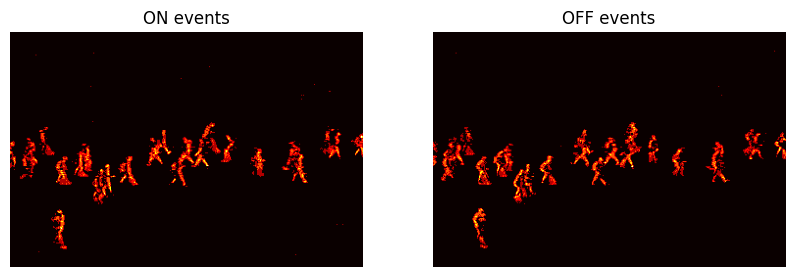

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(events[0], cmap='hot')
axs[0].set_title("ON events")

axs[1].imshow(events[1], cmap='hot')
axs[1].set_title("OFF events")

for ax in axs:
    ax.axis("off")

plt.show()


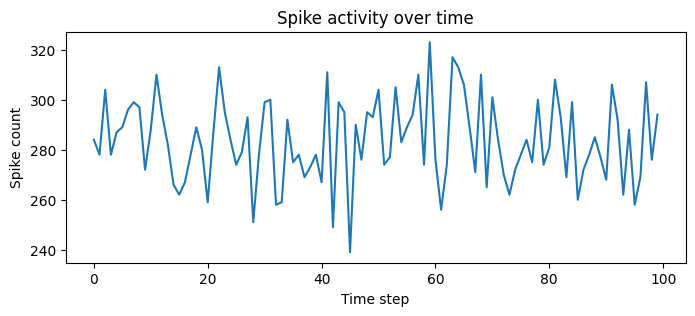

In [7]:
spike_counts = spikes.sum(axis=(0, 1, 2))

plt.figure(figsize=(8, 3))
plt.plot(spike_counts)
plt.xlabel("Time step")
plt.ylabel("Spike count")
plt.title("Spike activity over time")
plt.show()


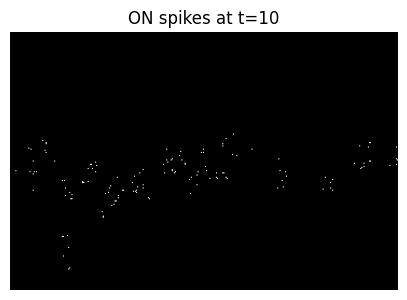

In [8]:
t = 10  # time step

plt.figure(figsize=(5, 4))
plt.imshow(spikes[0, :, :, t], cmap='gray')
plt.title(f"ON spikes at t={t}")
plt.axis("off")
plt.show()


In [9]:
total_neurons = np.prod(spikes.shape)
active_spikes = spikes.sum()

print(f"Sparsity: {active_spikes / total_neurons:.6f}")


Sparsity: 0.001641
